In [1]:
import csv
import math
import matplotlib.pyplot as plt
import numpy as np

from utils import (
    read_intensities, 
    read_kmer_positions,
    get_all_kmer_wildcards,
    get_sequence_from_fasta,
    match_all_kmers_to_wildcards,
    regression_driver
)

genome =  "../../../../../d/OneDrive - McGill University/repos/hg38_ucsc.fa"
intensities = read_intensities("./data/ENCFF003ZRP_ENCFF274YGF.ChIPBM.tf.txt")
kmers = read_kmer_positions("./data/ENCFF274YGF_K562_DNase-seq_Crawford_GRCh38.ChIPBM.array.txt")
dhs = 1
region = "chr6:41071098-41071113"
kmer_size = 8
num_random = 1000
mode="neg-binomial"



/home/aki/miniconda3/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
region = "chr5:1295220-1295260"
kmer_size = 8
num_random = 1000
mode="neg-binomial"

used_regions = set(kmers.keys())

chrom, coords = region.split(":")
start, end = map(int, coords.split("-"))
region_seq = get_sequence_from_fasta(chrom, start, end, genome)

rows = []

for i in range(len(region_seq) - kmer_size + 1):
    kmer_seq = region_seq[i:i + kmer_size]
    motif_start = start + i
    # print(f"\n[Window {i}] kmer_seq = {kmer_seq}")

    # === Step 2: Generate all possible wildcards at every position ===
    wildcard_variants = get_all_kmer_wildcards(kmer_seq)
    # print("  Wildcards:")
    # for pos, wildcard in wildcard_variants.items():
        # print(f"    Position {pos}: {wildcard}")

    # === Step 3: Match wildcards to genome-wide k-mers ===
    matched = match_all_kmers_to_wildcards(kmers, wildcard_variants)

    # print("  Matched wildcard positions:")
    for motif_pos in matched:
        for allele in matched[motif_pos]:
            count = len(matched[motif_pos][allele])
            # print(f"    Position {motif_pos}, Allele {allele}: {count} matches")

    # === Step 4: Run regression for each wildcard position and allele ===
    for motif_pos in matched:
        for allele in matched[motif_pos]:
            matched_block = {
                motif_pos: {
                    motif_pos: {
                        allele: matched[motif_pos][allele]
                    }
                }
            }

            try:
                aff_stats = regression_driver(
                    matched_block,
                    probe_intensities=intensities,
                    exclude_ref_allele=False,
                    dhs=dhs,
                    mode=mode
                )
            except Exception as e:
                print(f"[Warning] Regression failed for Window {i}, Pos {motif_pos}, Allele {allele}: {e}")
                aff_stats = {allele: (math.nan, None, math.nan)}

            coef, _, pval = aff_stats.get(allele, (math.nan, None, math.nan))
            absolute_pos = i + motif_pos

            wildcard_kmer = wildcard_variants[motif_pos]
            filled_kmer = list(wildcard_kmer)
            filled_kmer[motif_pos] = allele
            filled_kmer = ''.join(filled_kmer)

            rows.append([
                wildcard_kmer,
                filled_kmer,
                i,
                motif_pos,
                "AFF",
                allele,
                coef,
                pval,
                absolute_pos
            ])


In [3]:
import pandas as pd
df = pd.DataFrame(rows, columns=[
    "wildcard_kmer", "filled_kmer", "window_index", "snp_index", "type", "allele", "coef", "pval", "absolute_position"
    ])

# Print aff_rows
aff_rows = df[df["type"] == "AFF"].copy()
print(aff_rows)

     wildcard_kmer filled_kmer  window_index  snp_index type allele      coef  \
0         .TCCGCCA    CTCCGCCA             0          0  AFF      C -1.668241   
1         .TCCGCCA    TTCCGCCA             0          0  AFF      T -1.447105   
2         .TCCGCCA    GTCCGCCA             0          0  AFF      G -0.870033   
3         .TCCGCCA    ATCCGCCA             0          0  AFF      A -0.724025   
4         C.CCGCCA    CGCCGCCA             0          1  AFF      G -1.048597   
...            ...         ...           ...        ...  ...    ...       ...   
1083      TGTGCC.G    TGTGCCTG            33          6  AFF      T  0.213775   
1084      TGTGCCC.    TGTGCCCC            33          7  AFF      C -0.923778   
1085      TGTGCCC.    TGTGCCCA            33          7  AFF      A  0.075638   
1086      TGTGCCC.    TGTGCCCG            33          7  AFF      G -0.730421   
1087      TGTGCCC.    TGTGCCCT            33          7  AFF      T  0.705500   

              pval  absolut

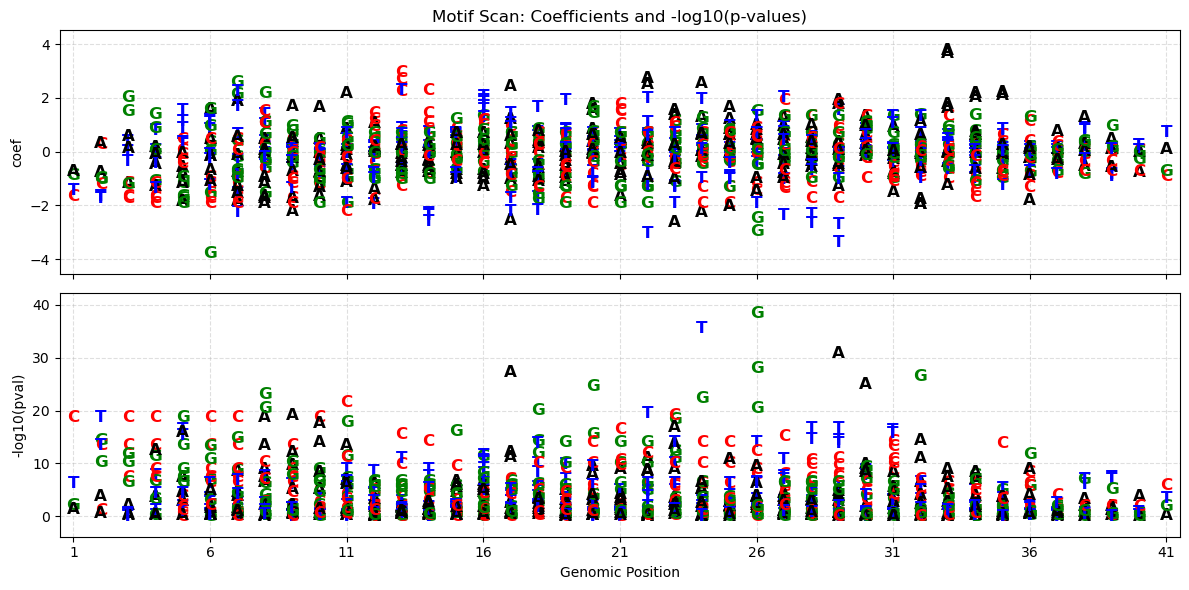

In [4]:
def plot_aff_motif_effects(rows):

    df = pd.DataFrame(rows, columns=[
        "wildcard_kmer", "filled_kmer", "window_index", "snp_index",
        "type", "allele", "coef", "pval", "absolute_pos"
    ])

    # Filter for AFF rows only
    df = df[df["type"] == "AFF"].copy()
    df["coef"] = pd.to_numeric(df["coef"], errors="coerce")
    df["pval"] = pd.to_numeric(df["pval"], errors="coerce")
    df["-log10(pval)"] = -np.log10(df["pval"])

    # Make x-axis 1-based instead of 0-based
    df["absolute_position"] = df["window_index"] + df["snp_index"] + 1
    region_length = df["absolute_position"].max()

    allele_colors = {
        "A": "black",
        "C": "red",
        "G": "green",
        "T": "blue"
    }

    fig_width = max(12, region_length * 0.15)
    fig, axs = plt.subplots(2, 1, figsize=(fig_width, 6), sharex=True)

    metrics = ["coef", "-log10(pval)"]

    for metric, ax in zip(metrics, axs):
        for _, row in df.iterrows():
            x = int(row["absolute_position"])
            y = row[metric]
            allele = row["allele"]
            color = allele_colors.get(allele, "gray")
            if pd.notna(y):
                ax.text(x, y, allele, color=color, fontsize=12, ha="center", va="center", fontweight="bold")

        # Y-axis limits with padding
        ymin = df[metric].min()
        ymax = df[metric].max()
        yrange = ymax - ymin if ymax != ymin else 1
        padding = yrange * 0.1
        ax.set_ylim(ymin - padding, ymax + padding)
        ax.set_ylabel(metric)
        ax.grid(True, linestyle="--", alpha=0.4)

    axs[1].set_xlabel("Genomic Position")
    axs[0].set_title("Motif Scan: Coefficients and -log10(p-values)")

    # X-axis ticks
    step = 10 if region_length > 80 else 5 if region_length > 40 else 1
    axs[1].set_xticks(range(1, region_length + 1, step))

    # Prevent overflow
    axs[1].set_xlim(0.5, region_length + 0.5)

    plt.tight_layout()
    plt.show()

plot_aff_motif_effects(rows)